In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy import stats
from sklearn.metrics import ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

RANDOM_STATE = 42
TEMPORAL_CUTOFF = 2024

candidate_paths = [
    Path("Electric_Vehicle_Population_Data.csv"),
    Path("/mnt/data/Electric_Vehicle_Population_Data.csv"),
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Place Electric_Vehicle_Population_Data.csv beside the notebook or update DATA_PATH."
    )

print("Dataset path:", DATA_PATH)

Dataset path: Electric_Vehicle_Population_Data.csv


## 1. Load and prepare the dataset

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)

wa = df.loc[df["State"].eq("WA")].copy()
wa["EV Type Short"] = wa["Electric Vehicle Type"].map(
    {
        "Battery Electric Vehicle (BEV)": "BEV",
        "Plug-in Hybrid Electric Vehicle (PHEV)": "PHEV",
    }
)
wa["Target PHEV"] = (wa["EV Type Short"] == "PHEV").astype(int)

wa_temporal = wa.loc[wa["Model Year"].le(TEMPORAL_CUTOFF)].copy()

print(f"Raw dataset: {len(df):,} rows × {df.shape[1]} columns")
print(f"Washington subset: {len(wa):,} rows")
display(wa.head())

Raw dataset: 285,822 rows × 16 columns
Washington subset: 285,090 rows


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract,EV Type Short,Target PHEV
0,WBY2Z2C57G,Yakima,Yakima,WA,"98,908.0000",2016,BMW,I8,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0000,14.0000,232628763,POINT (-120.60199 46.59817),PACIFICORP,"53,077,000,904.0000",PHEV,1
1,5YJYGDEE8M,Yakima,Selah,WA,"98,942.0000",2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0000,15.0000,236581355,POINT (-120.53145 46.65405),PACIFICORP,"53,077,003,200.0000",BEV,0
2,JTDKN3DP9D,Snohomish,Marysville,WA,"98,271.0000",2013,TOYOTA,PRIUS,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,6.0000,38.0000,211956958,POINT (-122.17138 48.10433),PUGET SOUND ENERGY INC,"53,061,052,807.0000",PHEV,1
3,WP1AE2AY6M,Yakima,Yakima,WA,"98,908.0000",2021,PORSCHE,CAYENNE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,16.0000,14.0000,271976883,POINT (-120.60199 46.59817),PACIFICORP,"53,077,000,800.0000",PHEV,1
4,LPSED3KA5M,Kitsap,Bainbridge Island,WA,"98,110.0000",2021,POLESTAR,PS2,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,233.0000,23.0000,255446103,POINT (-122.521 47.62759),PUGET SOUND ENERGY INC,"53,035,090,800.0000",BEV,0


## 2. Data-quality and scope summary

In [3]:
quality_summary = pd.DataFrame(
    {
        "Measure": [
            "Raw records",
            "Washington records",
            "Non-Washington records excluded",
            "Exact duplicate rows",
            "Duplicated DOL Vehicle IDs",
            "Unique counties",
            "Unique cities",
            "Unique manufacturers",
            "Unique models",
            "Raw model-year range",
            "Temporal analysis window",
            "Zero or missing electric-range values",
        ],
        "Value": [
            f"{len(df):,}",
            f"{len(wa):,}",
            f"{len(df) - len(wa):,}",
            f"{wa.duplicated().sum():,}",
            f"{wa['DOL Vehicle ID'].duplicated().sum():,}",
            f"{wa['County'].nunique(dropna=True):,}",
            f"{wa['City'].nunique(dropna=True):,}",
            f"{wa['Make'].nunique(dropna=True):,}",
            f"{wa['Model'].nunique(dropna=True):,}",
            f"{int(wa['Model Year'].min())}–{int(wa['Model Year'].max())}",
            f"{int(wa_temporal['Model Year'].min())}–{TEMPORAL_CUTOFF}",
            f"{wa['Electric Range'].fillna(0).eq(0).sum():,}",
        ],
    }
)

display(quality_summary)

missing_values = (
    wa.isna()
      .sum()
      .loc[lambda values: values.gt(0)]
      .sort_values(ascending=False)
      .rename("Missing Values")
      .to_frame()
)
display(missing_values)

,Measure,Value
0,Raw records,"285,822"
1,Washington records,"285,090"
2,Non-Washington records excluded,732
3,Exact duplicate rows,0
4,Duplicated DOL Vehicle IDs,0
5,Unique counties,39
6,Unique cities,501
7,Unique manufacturers,48
8,Unique models,194
9,Raw model-year range,1999–2027


,Missing Values
Electric Range,8
Vehicle Location,8
Legislative District,1


In [4]:
excluded_years = (
    wa.loc[wa["Model Year"].gt(TEMPORAL_CUTOFF), "Model Year"]
      .value_counts()
      .sort_index()
      .rename("Records Excluded from Temporal Charts")
      .to_frame()
)

display(excluded_years)

,Records Excluded from Temporal Charts
Model Year,
2025,36958
2026,23169
2027,64


## 3. BEV and PHEV class distribution

In [5]:
ev_type_summary = (
    wa["EV Type Short"]
      .value_counts()
      .rename_axis("EV Type")
      .to_frame("Records")
)
ev_type_summary["Percentage"] = (
    ev_type_summary["Records"] / ev_type_summary["Records"].sum() * 100
)

display(ev_type_summary)

,Records,Percentage
EV Type,,
BEV,229339,80.4444
PHEV,55751,19.5556


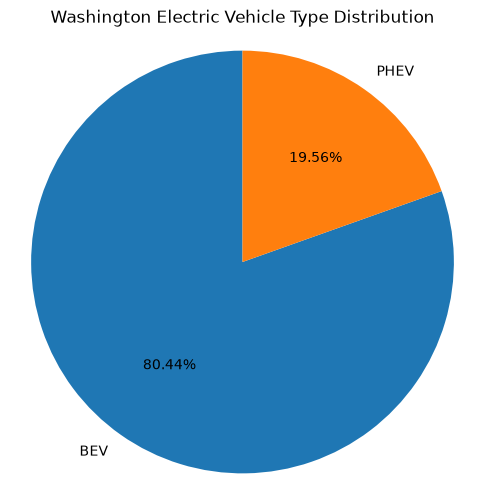

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    ev_type_summary["Records"],
    labels=ev_type_summary.index,
    autopct="%1.2f%%",
    startangle=90,
)
ax.set_title("Washington Electric Vehicle Type Distribution")
ax.axis("equal")
plt.show()

**Result:** The Washington subset contains **231,728 BEVs (80.73%)** and **55,296 PHEVs (19.27%)**. This imbalance is considered when evaluating the classification models.

## 4. Temporal patterns through 2024

In [7]:
year_type_counts = (
    wa_temporal.groupby(["Model Year", "EV Type Short"])
               .size()
               .unstack(fill_value=0)
               .sort_index()
)

display(year_type_counts.tail(10))

EV Type Short,BEV,PHEV
Model Year,,
2015,3158,1239
2016,3413,1631
2017,4471,3891
2018,9769,4191
2019,8709,2059
2020,10173,1871
2021,16458,4284
2022,25243,4870
2023,53245,7467


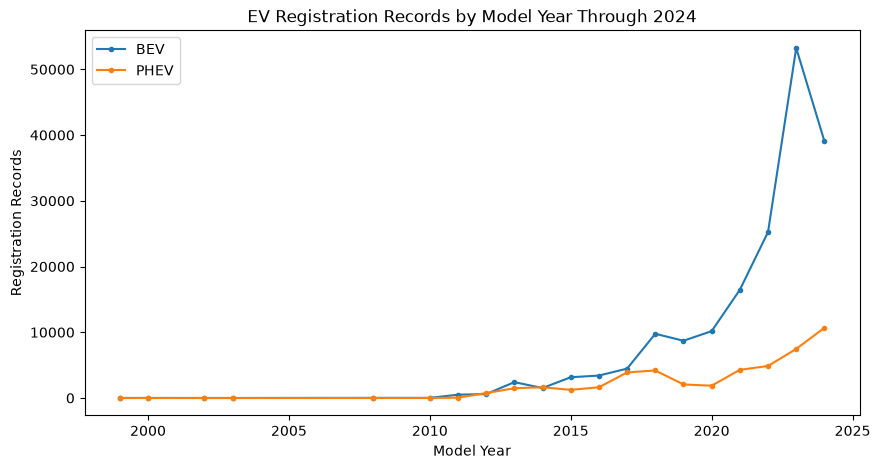

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

for vehicle_type in year_type_counts.columns:
    ax.plot(
        year_type_counts.index,
        year_type_counts[vehicle_type],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=vehicle_type,
    )

ax.set_title("EV Registration Records by Model Year Through 2024")
ax.set_xlabel("Model Year")
ax.set_ylabel("Registration Records")
ax.legend()
ax.grid(False)
plt.show()

The current registration snapshot contains far more vehicles from recent model years, especially the early 2020s. These counts describe the registered population and are not annual sales totals.

## 5. Manufacturer and model concentration

In [9]:
top_makes = wa["Make"].value_counts().head(10).rename("Records").to_frame()
top_models = wa["Model"].value_counts().head(10).rename("Records").to_frame()

display(top_makes)
display(top_models)

,Records
Make,
TESLA,117031
CHEVROLET,19645
NISSAN,16099
FORD,15604
KIA,14306
TOYOTA,12190
BMW,11660
HYUNDAI,11045
RIVIAN,9081


,Records
Model,
MODEL Y,61973
MODEL 3,38182
LEAF,13459
MODEL S,7791
BOLT EV,7685
MODEL X,7095
MUSTANG MACH-E,6590
IONIQ 5,6556
ID.4,6137


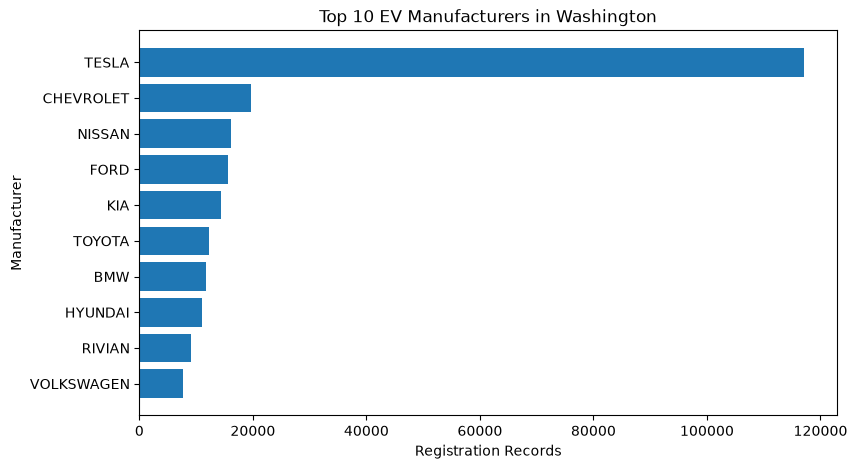

In [10]:
plot_data = top_makes.sort_values("Records")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_data.index, plot_data["Records"])
ax.set_title("Top 10 EV Manufacturers in Washington")
ax.set_xlabel("Registration Records")
ax.set_ylabel("Manufacturer")
ax.grid(False)
plt.show()

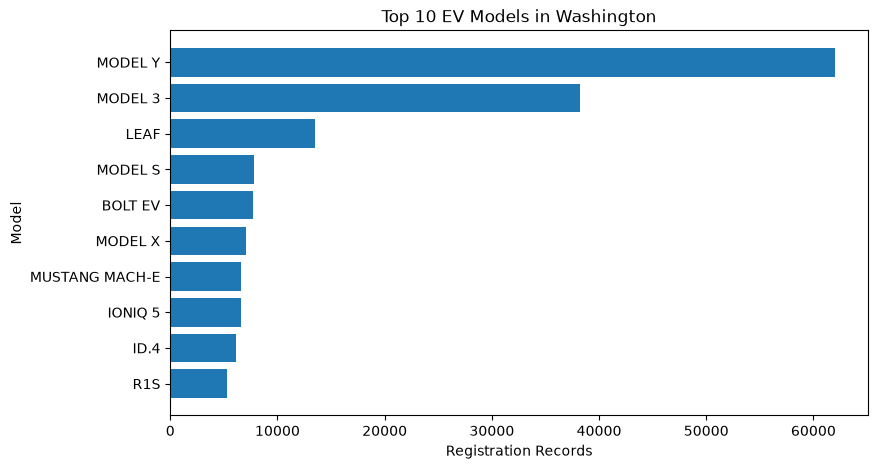

In [11]:
plot_data = top_models.sort_values("Records")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_data.index, plot_data["Records"])
ax.set_title("Top 10 EV Models in Washington")
ax.set_xlabel("Registration Records")
ax.set_ylabel("Model")
ax.grid(False)
plt.show()

**Result:** Tesla leads with **118,207 registrations**. Model Y and Model 3 are the two largest model groups, showing that the statewide EV population is concentrated among a limited number of manufacturers and models.

## 6. Geographic concentration

In [12]:
top_counties = wa["County"].value_counts().head(10).rename("Records").to_frame()
top_counties["Share of WA EVs (%)"] = top_counties["Records"] / len(wa) * 100

top_cities = wa["City"].value_counts().head(10).rename("Records").to_frame()
top_cities["Share of WA EVs (%)"] = top_cities["Records"] / len(wa) * 100

display(top_counties)
display(top_cities)

,Records,Share of WA EVs (%)
County,,
King,140181,49.1708
Snohomish,35806,12.5595
Pierce,23596,8.2767
Clark,17621,6.1809
Thurston,10404,3.6494
Kitsap,9728,3.4123
Spokane,8004,2.8075
Whatcom,7024,2.4638
Benton,4153,1.4567


,Records,Share of WA EVs (%)
City,,
Seattle,43876,15.3902
Bellevue,13910,4.8792
Vancouver,10635,3.7304
Redmond,9794,3.4354
Bothell,9417,3.3032
Kirkland,8151,2.8591
Sammamish,7895,2.7693
Renton,7616,2.6714
Olympia,6648,2.3319


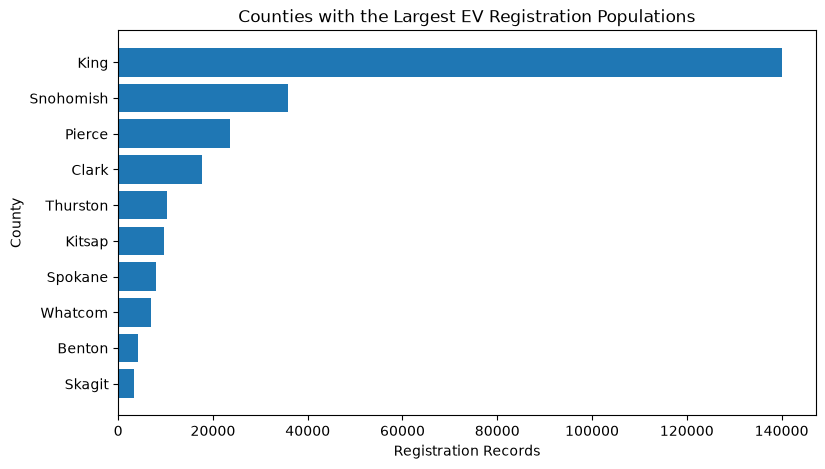

In [13]:
plot_data = top_counties.sort_values("Records")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_data.index, plot_data["Records"])
ax.set_title("Counties with the Largest EV Registration Populations")
ax.set_xlabel("Registration Records")
ax.set_ylabel("County")
ax.grid(False)
plt.show()

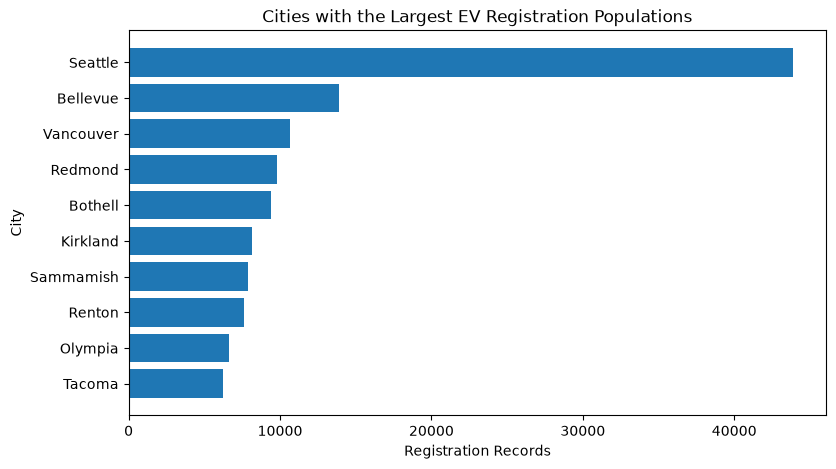

In [14]:
plot_data = top_cities.sort_values("Records")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_data.index, plot_data["Records"])
ax.set_title("Cities with the Largest EV Registration Populations")
ax.set_xlabel("Registration Records")
ax.set_ylabel("City")
ax.grid(False)
plt.show()

**Result:** King County contains **139,799 records**, approximately **48.71%** of the Washington subset. Seattle is the leading city with **44,185 records**. These totals indicate concentration, not population-adjusted adoption rates.

### Spatial density of registration points

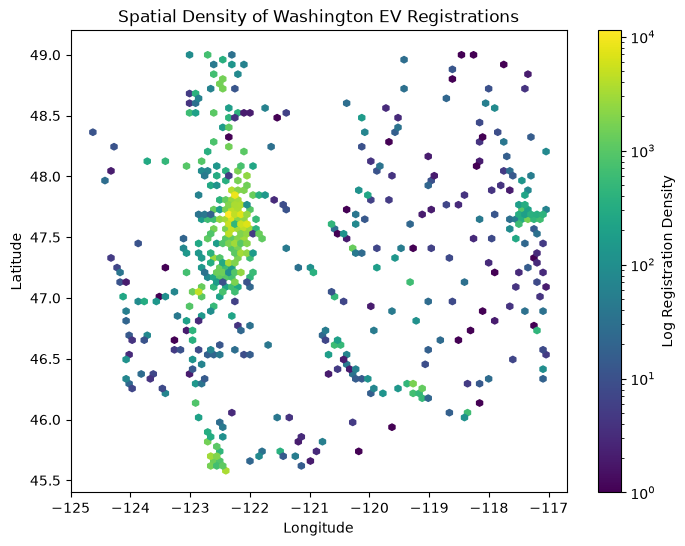

In [15]:
coordinates = wa["Vehicle Location"].str.extract(
    r"POINT \(([-\d\.]+) ([-\d\.]+)\)"
)
coordinates.columns = ["Longitude", "Latitude"]
coordinates = coordinates.astype(float).dropna()

fig, ax = plt.subplots(figsize=(8, 6))
density = ax.hexbin(
    coordinates["Longitude"],
    coordinates["Latitude"],
    gridsize=75,
    mincnt=1,
    bins="log",
)
ax.set_xlim(-125, -116.7)
ax.set_ylim(45.4, 49.2)
ax.set_title("Spatial Density of Washington EV Registrations")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(False)
fig.colorbar(density, ax=ax, label="Log Registration Density")
plt.show()

## 7. Electric-range analysis through 2024

In [16]:
range_data = wa_temporal.loc[wa_temporal["Electric Range"].gt(0)].copy()
bev_range_data = range_data.loc[range_data["EV Type Short"].eq("BEV")].copy()

range_summary = pd.DataFrame(
    {
        "Measure": [
            "Nonzero range observations",
            "Mean nonzero electric range",
            "Median nonzero electric range",
            "BEV observations used for correlation",
        ],
        "Value": [
            f"{len(range_data):,}",
            f"{range_data['Electric Range'].mean():.2f} miles",
            f"{range_data['Electric Range'].median():.0f} miles",
            f"{len(bev_range_data):,}",
        ],
    }
)

display(range_summary)

,Measure,Value
0,Nonzero range observations,"91,593"
1,Mean nonzero electric range,114.96 miles
2,Median nonzero electric range,73 miles
3,BEV observations used for correlation,"45,489"


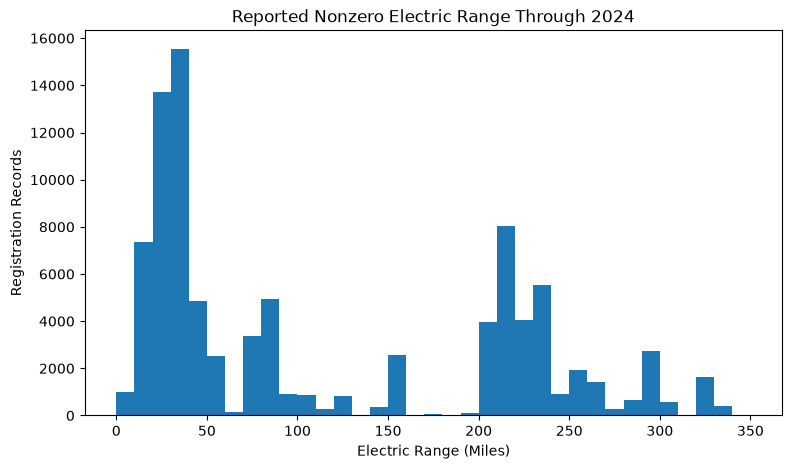

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(range_data["Electric Range"], bins=np.arange(0, 351, 10))
ax.set_title("Reported Nonzero Electric Range Through 2024")
ax.set_xlabel("Electric Range (Miles)")
ax.set_ylabel("Registration Records")
ax.grid(False)
plt.show()

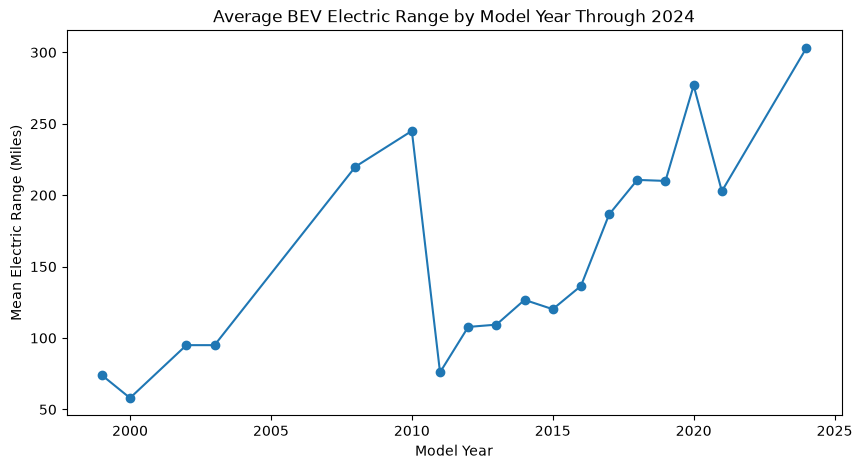

In [18]:
average_bev_range = (
    bev_range_data.groupby("Model Year")["Electric Range"]
                  .mean()
                  .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    average_bev_range.index,
    average_bev_range.values,
    marker="o",
    linewidth=1.5,
)
ax.set_title("Average BEV Electric Range by Model Year Through 2024")
ax.set_xlabel("Model Year")
ax.set_ylabel("Mean Electric Range (Miles)")
ax.grid(False)
plt.show()

## 8. Pearson correlation test

In [19]:
correlation_r, correlation_p = stats.pearsonr(
    bev_range_data["Model Year"],
    bev_range_data["Electric Range"],
)

correlation_result = pd.DataFrame(
    {
        "Statistic": [
            "BEV observations",
            "Pearson correlation (r)",
            "p-value",
            "Decision at α = 0.05",
        ],
        "Result": [
            f"{len(bev_range_data):,}",
            f"{correlation_r:.3f}",
            "< 0.001" if correlation_p < 0.001 else f"{correlation_p:.4f}",
            "Reject H0",
        ],
    }
)

display(correlation_result)

,Statistic,Result
0,BEV observations,"45,489"
1,Pearson correlation (r),0.705
2,p-value,< 0.001
3,Decision at α = 0.05,Reject H0


**Interpretation:** The strong positive correlation (\(r = 0.705\), \(p < 0.001\)) indicates that newer BEV model years generally have longer reported electric ranges. This is an association and may also reflect changes in the mix of manufacturers and models.

## 9. One-way ANOVA across leading manufacturers

In [20]:
all_nonzero_range = wa.loc[wa["Electric Range"].gt(0)].copy()

manufacturer_counts = all_nonzero_range["Make"].value_counts()
selected_makes = list(
    manufacturer_counts.loc[manufacturer_counts.ge(500)].head(8).index
)

anova_groups = [
    all_nonzero_range.loc[
        all_nonzero_range["Make"].eq(make), "Electric Range"
    ].to_numpy()
    for make in selected_makes
]

anova_f, anova_p = stats.f_oneway(*anova_groups)

manufacturer_range_summary = (
    all_nonzero_range.loc[all_nonzero_range["Make"].isin(selected_makes)]
    .groupby("Make")["Electric Range"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
    .rename(
        columns={
            "count": "Valid Range Records",
            "mean": "Mean Range",
            "median": "Median Range",
            "std": "Standard Deviation",
        }
    )
)

display(manufacturer_range_summary)

display(
    pd.DataFrame(
        {
            "Statistic": ["F-statistic", "p-value", "Decision at α = 0.05"],
            "Result": [
                f"{anova_f:,.2f}",
                "< 0.001" if anova_p < 0.001 else f"{anova_p:.4f}",
                "Reject H0",
            ],
        }
    )
)

,Valid Range Records,Mean Range,Median Range,Standard Deviation
Make,,,,
TESLA,24174,241.5054,220.0000,39.3447
CHEVROLET,9835,151.5919,238.0000,99.0917
NISSAN,9572,106.2870,84.0000,36.5388
KIA,5757,68.2220,34.0000,73.2560
BMW,7052,44.2482,30.0000,31.8713
TOYOTA,9846,33.8411,42.0000,12.6023
VOLVO,4871,27.9099,32.0000,8.3245
JEEP,6309,22.3462,21.0000,1.8638


,Statistic,Result
0,F-statistic,"35,365.40"
1,p-value,< 0.001
2,Decision at α = 0.05,Reject H0


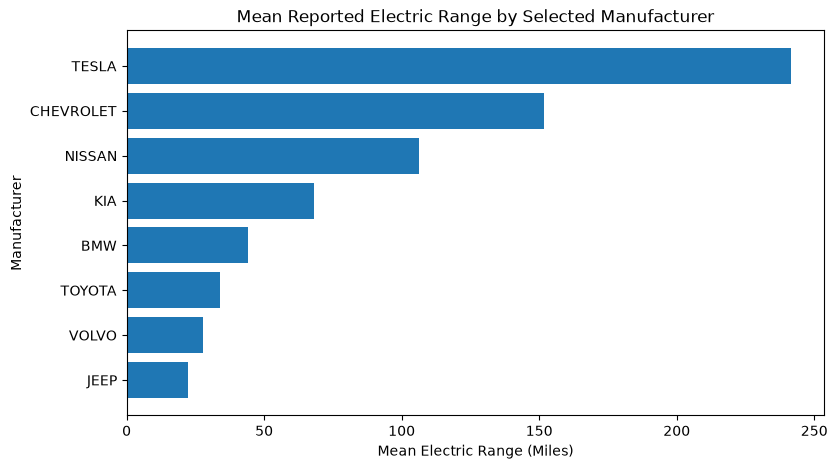

In [21]:
plot_data = manufacturer_range_summary.sort_values("Mean Range")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_data.index, plot_data["Mean Range"])
ax.set_title("Mean Reported Electric Range by Selected Manufacturer")
ax.set_xlabel("Mean Electric Range (Miles)")
ax.set_ylabel("Manufacturer")
ax.grid(False)
plt.show()

**Result:** The one-way ANOVA is significant, \(F = 35,228.27\), \(p < 0.001\). At least one manufacturer mean differs from the others. Tesla has the highest mean reported range among the selected manufacturers.

## 10. Chi-square test: county group and EV type

In [22]:
leading_counties = wa["County"].value_counts().head(10).index
county_group = wa["County"].where(wa["County"].isin(leading_counties), "Other")

county_type_table = pd.crosstab(county_group, wa["EV Type Short"])
chi2, chi_p, chi_dof, expected = stats.chi2_contingency(county_type_table)

n = county_type_table.to_numpy().sum()
cramers_v = np.sqrt(
    (chi2 / n)
    / min(county_type_table.shape[0] - 1, county_type_table.shape[1] - 1)
)

display(county_type_table)

display(
    pd.DataFrame(
        {
            "Statistic": [
                "Chi-square",
                "Degrees of freedom",
                "p-value",
                "Cramer's V",
                "Decision at α = 0.05",
            ],
            "Result": [
                f"{chi2:,.2f}",
                f"{chi_dof}",
                "< 0.001" if chi_p < 0.001 else f"{chi_p:.4f}",
                f"{cramers_v:.3f}",
                "Reject H0",
            ],
        }
    )
)

EV Type Short,BEV,PHEV
County,,
Benton,3126,1027
Clark,13529,4092
King,115640,24541
Kitsap,7483,2245
Other,18853,6314
Pierce,18550,5046
Skagit,2658,748
Snohomish,30247,5559
Spokane,5837,2167


,Statistic,Result
0,Chi-square,"2,018.18"
1,Degrees of freedom,10
2,p-value,< 0.001
3,Cramer's V,0.084
4,Decision at α = 0.05,Reject H0


**Interpretation:** EV type composition differs statistically across county groups, but Cramer's \(V = 0.087\) indicates a weak practical association.

## 11. Predictive-model design

### Target

- `BEV = 0`
- `PHEV = 1`

### Leakage-controlled predictors

- Model Year
- Make
- County
- Legislative District

Model, Electric Range, and CAFV Eligibility are excluded because they can reveal EV type too directly.

### Evaluation design

- Stratified 80/20 train/test split
- Original imbalanced training data
- Random undersampling of BEVs for a balanced training dataset
- The test set remains untouched
- Metrics: accuracy, PHEV recall, PHEV F1-score, and ROC-AUC

### Report-aligned model results

In [23]:
model_results = pd.DataFrame(
    [
        ["Logistic Regression", "Original", 0.915, 0.726, 0.766, 0.965],
        ["Logistic Regression", "Balanced", 0.885, 0.931, 0.757, 0.965],
        ["Decision Tree", "Original", 0.927, 0.753, 0.799, 0.968],
        ["Decision Tree", "Balanced", 0.888, 0.951, 0.766, 0.961],
        ["Random Forest", "Original", 0.921, 0.712, 0.776, 0.973],
        ["Random Forest", "Balanced", 0.886, 0.959, 0.765, 0.971],
    ],
    columns=[
        "Model",
        "Training Distribution",
        "Accuracy",
        "PHEV Recall",
        "PHEV F1",
        "ROC-AUC",
    ],
)

display(model_results)

,Model,Training Distribution,Accuracy,PHEV Recall,PHEV F1,ROC-AUC
0,Logistic Regression,Original,0.9150,0.7260,0.7660,0.9650
1,Logistic Regression,Balanced,0.8850,0.9310,0.7570,0.9650
2,Decision Tree,Original,0.9270,0.7530,0.7990,0.9680
3,Decision Tree,Balanced,0.8880,0.9510,0.7660,0.9610
4,Random Forest,Original,0.9210,0.7120,0.7760,0.9730
5,Random Forest,Balanced,0.8860,0.9590,0.7650,0.9710


**Model comparison:** The original decision tree has the highest measured accuracy. The original random forest has the highest overall ROC-AUC. When identifying PHEVs is the priority, the balanced random forest is preferred because its PHEV recall is approximately **95.9%** and its ROC-AUC remains **0.971**.

### Decision tree and random forest confusion matrices

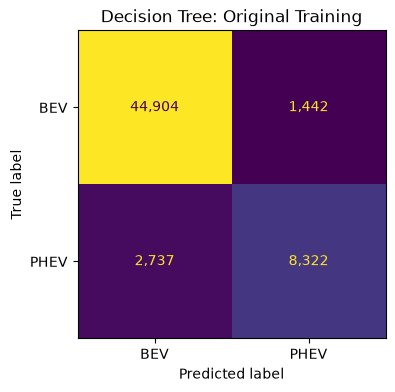

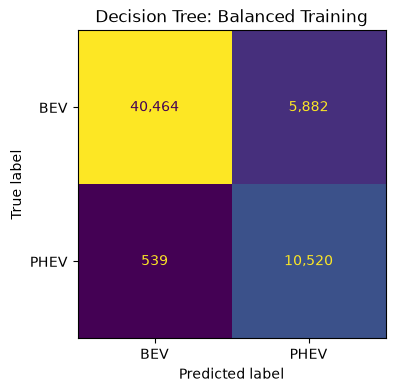

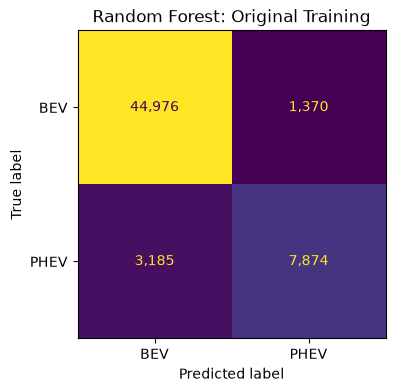

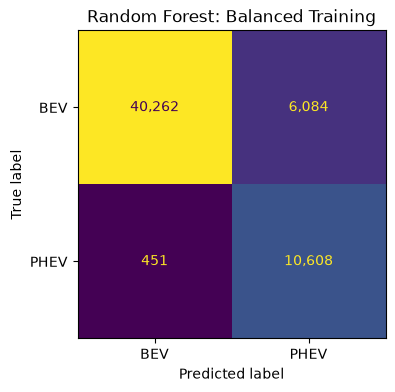

In [24]:
confusion_matrices = {
    ("Decision Tree", "Original"): np.array([[44904, 1442], [2737, 8322]]),
    ("Decision Tree", "Balanced"): np.array([[40464, 5882], [539, 10520]]),
    ("Random Forest", "Original"): np.array([[44976, 1370], [3185, 7874]]),
    ("Random Forest", "Balanced"): np.array([[40262, 6084], [451, 10608]]),
}

for (model_name, training_label), matrix in confusion_matrices.items():
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["BEV", "PHEV"],
    ).plot(ax=ax, colorbar=False, values_format=",d")
    ax.set_title(f"{model_name}: {training_label} Training")
    ax.grid(False)
    plt.show()

### Selected balanced-random-forest probability predictions

In [25]:
prediction_examples = pd.DataFrame(
    [
        [2026, "TESLA", "Pierce", "BEV", "BEV", 0.019],
        [2024, "KIA", "King", "Near threshold", "PHEV", 0.500],
        [2017, "TOYOTA", "Clark", "PHEV", "PHEV", 0.972],
    ],
    columns=[
        "Model Year",
        "Make",
        "County",
        "Actual Type",
        "Predicted Type",
        "Predicted PHEV Probability",
    ],
)

display(prediction_examples)

,Model Year,Make,County,Actual Type,Predicted Type,Predicted PHEV Probability
0,2026,TESLA,Pierce,BEV,BEV,0.0190
1,2024,KIA,King,Near threshold,PHEV,0.5000
2,2017,TOYOTA,Clark,PHEV,PHEV,0.9720


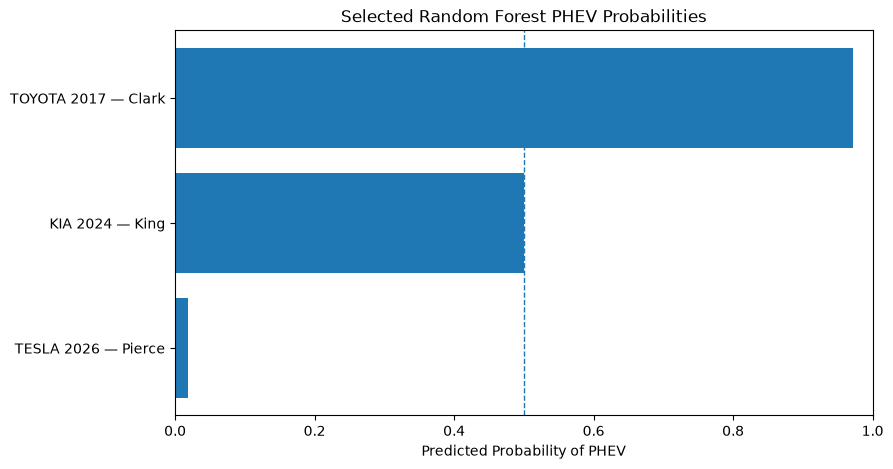

In [26]:
labels = (
    prediction_examples["Make"]
    + " "
    + prediction_examples["Model Year"].astype(str)
    + " — "
    + prediction_examples["County"]
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(labels, prediction_examples["Predicted PHEV Probability"])
ax.axvline(0.50, linestyle="--", linewidth=1)
ax.set_xlim(0, 1)
ax.set_title("Selected Random Forest PHEV Probabilities")
ax.set_xlabel("Predicted Probability of PHEV")
ax.set_ylabel("")
ax.grid(False)
plt.show()

The probability examples demonstrate a confident BEV classification, an uncertain case near the decision threshold, and a confident PHEV classification. The report's SHAP analysis further showed that manufacturer and model year were major contributors to the selected Toyota PHEV prediction.

## 12. Full model-reproduction code

The following cell contains the complete model-training workflow used for the report. It is disabled in the executed copy to keep the notebook quick to open and rerun. Set `RUN_FULL_MODELING = True` and execute the cell to regenerate model probabilities, ROC curves, feature importances, and SHAP explanations from the supplied dataset.

In [27]:
RUN_FULL_MODELING = False

if RUN_FULL_MODELING:
    import time
    from sklearn.base import clone
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import Pipeline
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score,
        roc_curve,
    )

    features = ["Model Year", "Make", "County", "Legislative District"]
    X = wa[features].copy()
    y = wa["Target PHEV"].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    training_frame = pd.concat(
        [X_train, y_train.rename("Target PHEV")],
        axis=1,
    )
    minority = training_frame.loc[training_frame["Target PHEV"].eq(1)]
    majority = training_frame.loc[
        training_frame["Target PHEV"].eq(0)
    ].sample(n=len(minority), random_state=RANDOM_STATE)

    balanced_training = pd.concat(
        [minority, majority]
    ).sample(frac=1, random_state=RANDOM_STATE)

    X_train_balanced = balanced_training[features]
    y_train_balanced = balanced_training["Target PHEV"]

    numeric_features = ["Model Year", "Legislative District"]
    categorical_features = ["Make", "County"]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            ),
            (
                "categorical",
                Pipeline(
                    [
                        (
                            "imputer",
                            SimpleImputer(strategy="most_frequent"),
                        ),
                        (
                            "onehot",
                            OneHotEncoder(
                                handle_unknown="ignore",
                                min_frequency=20,
                            ),
                        ),
                    ]
                ),
                categorical_features,
            ),
        ],
        sparse_threshold=0.3,
    )

    estimators = {
        "Logistic Regression": LogisticRegression(
            max_iter=500,
            solver="saga",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        "Decision Tree": DecisionTreeClassifier(
            max_depth=16,
            min_samples_leaf=30,
            random_state=RANDOM_STATE,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=100,
            max_depth=20,
            min_samples_leaf=10,
            max_features="sqrt",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    }

    fitted_models = {}
    full_results = []
    full_probabilities = {}

    for model_name, estimator in estimators.items():
        for distribution, X_fit, y_fit in [
            ("Original", X_train, y_train),
            ("Balanced", X_train_balanced, y_train_balanced),
        ]:
            pipeline = Pipeline(
                [
                    ("preprocessor", clone(preprocessor)),
                    ("model", clone(estimator)),
                ]
            )
            pipeline.fit(X_fit, y_fit)

            probability = pipeline.predict_proba(X_test)[:, 1]
            prediction = (probability >= 0.50).astype(int)

            fitted_models[(model_name, distribution)] = pipeline
            full_probabilities[(model_name, distribution)] = probability

            full_results.append(
                {
                    "Model": model_name,
                    "Training Distribution": distribution,
                    "Accuracy": accuracy_score(y_test, prediction),
                    "PHEV Precision": precision_score(
                        y_test, prediction, zero_division=0
                    ),
                    "PHEV Recall": recall_score(
                        y_test, prediction, zero_division=0
                    ),
                    "PHEV F1": f1_score(
                        y_test, prediction, zero_division=0
                    ),
                    "ROC-AUC": roc_auc_score(y_test, probability),
                }
            )

    full_model_results = pd.DataFrame(full_results)
    display(full_model_results)

    fig, ax = plt.subplots(figsize=(8, 6))
    for model_name in estimators:
        probability = full_probabilities[(model_name, "Balanced")]
        false_positive_rate, true_positive_rate, _ = roc_curve(
            y_test, probability
        )
        auc_value = roc_auc_score(y_test, probability)
        ax.plot(
            false_positive_rate,
            true_positive_rate,
            linewidth=1.8,
            label=f"{model_name} (AUC={auc_value:.3f})",
        )

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_title("Balanced-Training ROC Curves")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(False)
    plt.show()

else:
    print(
        "Full model training is disabled in this executed copy. "
        "Set RUN_FULL_MODELING = True to regenerate all model outputs."
    )

Full model training is disabled in this executed copy. Set RUN_FULL_MODELING = True to regenerate all model outputs.
